> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 13. Logistic Regression

*Scope:* The linear model adapted to classification: a squashing function, a likelihood, and a decision boundary.

The first classifier, and — despite the name — a classification model rather than a regression one. It
keeps linear regression's weighted sum and adds two things: a function that squashes that sum into $[0,1]$,
and a loss built for probabilities instead of distances.

It remains the default first model for binary classification on tabular data: fast, calibrated out of the
box (8.7), and the only classifier in this material whose coefficients can be read directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 115)
sns.set_theme(style="whitegrid")

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print("ready")

ready


### 13.1 From Regression to Classification

The obvious idea is to fit a linear regression to a 0/1 target and threshold its output at 0.5. It fails
in two specific ways, and both are worth seeing before the fix.

In [2]:
from sklearn.linear_model import LinearRegression

# Hours studied vs pass/fail.
hours = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]).reshape(-1, 1)
passed = np.array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1])

linear = LinearRegression().fit(hours, passed)

probe = np.array([[-1.0], [0.0], [3.0], [9.0], [12.0]])
for xv, pred in zip(probe.ravel(), linear.predict(probe)):
    flag = "   <- not a probability" if pred < 0 or pred > 1 else ""
    print(f"hours {xv:>5.1f}  ->  {pred:>7.3f}{flag}")

hours  -1.0  ->   -0.510   <- not a probability
hours   0.0  ->   -0.273   <- not a probability
hours   3.0  ->    0.441
hours   9.0  ->    1.867   <- not a probability
hours  12.0  ->    2.580   <- not a probability


**Failure 1 — the output is unbounded.** A linear function extends forever in both directions, so it
predicts negative "probabilities" for small inputs and values above 1 for large ones. There is no
interpretation of $-0.28$ as a probability.

**Failure 2 — outliers rotate the decision boundary.** Squared loss penalizes a confidently-correct point
that sits far from the line, so adding a student who studied for 25 hours and passed *drags the boundary*
even though it adds no new information about where the boundary should be.

In [3]:
hours_ext = np.vstack([hours, [[25.0]]])
passed_ext = np.r_[passed, 1]

linear_ext = LinearRegression().fit(hours_ext, passed_ext)

def boundary(model):
    """Where does the fitted line cross 0.5?"""
    return (0.5 - model.intercept_) / model.coef_[0]

print(f"linear boundary, without the distant point: {boundary(linear):.2f} hours")
print(f"linear boundary, with it                  : {boundary(linear_ext):.2f} hours")

logit = LogisticRegression().fit(hours, passed)
logit_ext = LogisticRegression().fit(hours_ext, passed_ext)
print(f"\nlogistic boundary, without : "
      f"{-logit.intercept_[0] / logit.coef_[0][0]:.2f} hours")
print(f"logistic boundary, with    : "
      f"{-logit_ext.intercept_[0] / logit_ext.coef_[0][0]:.2f} hours")

linear boundary, without the distant point: 3.25 hours
linear boundary, with it                  : 3.94 hours

logistic boundary, without : 3.25 hours
logistic boundary, with    : 3.25 hours


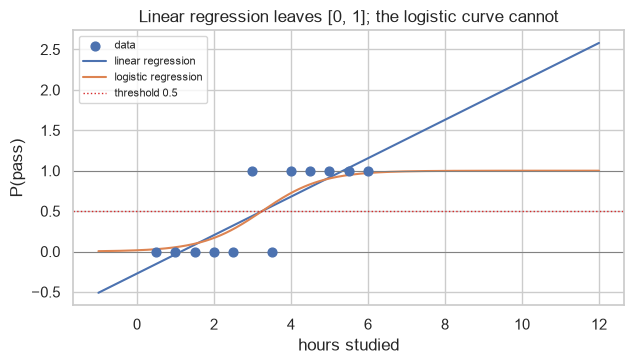

In [4]:
grid = np.linspace(-1, 12, 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.scatter(hours, passed, s=40, zorder=3, label="data")
ax.plot(grid, linear.predict(grid), label="linear regression")
ax.plot(grid, logit.predict_proba(grid)[:, 1], label="logistic regression")
ax.axhline(0, color="gray", lw=0.7); ax.axhline(1, color="gray", lw=0.7)
ax.axhline(0.5, color="tab:red", ls=":", lw=1, label="threshold 0.5")
ax.set_xlabel("hours studied"); ax.set_ylabel("P(pass)")
ax.set_title("Linear regression leaves [0, 1]; the logistic curve cannot")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The fix for both failures is the same: pass the linear score through a function that is bounded, and
replace squared loss with one built for probabilities.

### 13.2 The Sigmoid, Odds and Log-Odds

The **logistic (sigmoid) function** maps any real number into $(0, 1)$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

| $z$ | $\sigma(z)$ |
|---|---|
| $-\infty$ | 0 |
| $-2$ | 0.12 |
| 0 | **0.5** |
| $+2$ | 0.88 |
| $+\infty$ | 1 |

The model is then linear regression's score fed through it:

$$\hat{p} = P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}\cdot\mathbf{x} + b)$$

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


for z in (-6, -2, -1, 0, 1, 2, 6):
    print(f"sigmoid({z:>3}) = {sigmoid(z):.4f}")

print("\nbounded:", sigmoid(-1000), "to", sigmoid(1000))
print("symmetric about 0:", np.isclose(sigmoid(2) + sigmoid(-2), 1.0))

sigmoid( -6) = 0.0025
sigmoid( -2) = 0.1192
sigmoid( -1) = 0.2689
sigmoid(  0) = 0.5000
sigmoid(  1) = 0.7311
sigmoid(  2) = 0.8808
sigmoid(  6) = 0.9975

bounded: 0.0 to 1.0
symmetric about 0: True


C:\Users\shayan.saha\AppData\Local\Temp\ipykernel_22992\4075704602.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


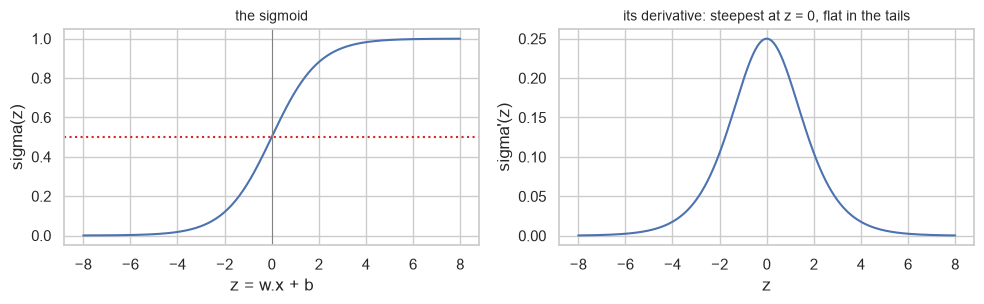

In [6]:
z = np.linspace(-8, 8, 400)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

axes[0].plot(z, sigmoid(z))
axes[0].axhline(0.5, color="tab:red", ls=":"); axes[0].axvline(0, color="gray", lw=0.7)
axes[0].set_xlabel("z = w.x + b"); axes[0].set_ylabel("sigma(z)")
axes[0].set_title("the sigmoid", fontsize=10)

axes[1].plot(z, sigmoid(z) * (1 - sigmoid(z)))
axes[1].set_xlabel("z"); axes[1].set_ylabel("sigma'(z)")
axes[1].set_title("its derivative: steepest at z = 0, flat in the tails", fontsize=10)

fig.tight_layout()
plt.show()

The derivative has a convenient closed form that 13.4 uses directly:

$$\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$$

In [7]:
h = 1e-6
numerical = (sigmoid(z + h) - sigmoid(z - h)) / (2 * h)
analytic = sigmoid(z) * (1 - sigmoid(z))
print("analytic derivative matches numerical:", np.allclose(analytic, numerical))

analytic derivative matches numerical: True


#### 13.2.1 Odds and log-odds

The sigmoid has an inverse, and the inverse is what makes the coefficients interpretable.

**Odds** are the ratio of the probability of an event to its complement:

$$\text{odds} = \frac{p}{1-p}$$

Taking the logarithm gives the **log-odds**, or **logit** — and rearranging the model shows that the linear
score *is* the log-odds:

$$\log\!\frac{\hat{p}}{1-\hat{p}} = \mathbf{w}\cdot\mathbf{x} + b = z$$

| Probability | Odds | Log-odds |
|---|---|---|
| 0.10 | 1 : 9 = 0.11 | −2.20 |
| 0.25 | 1 : 3 = 0.33 | −1.10 |
| 0.50 | 1 : 1 = 1.00 | **0** |
| 0.75 | 3 : 1 = 3.00 | +1.10 |
| 0.90 | 9 : 1 = 9.00 | +2.20 |

**This is the sentence that makes logistic regression interpretable: the model is linear in the log-odds.**
A one-unit increase in $x_j$ adds $w_j$ to the log-odds, which *multiplies* the odds by $e^{w_j}$ (13.8).

In [8]:
def logit_fn(p):
    return np.log(p / (1 - p))


for p in (0.1, 0.25, 0.5, 0.75, 0.9):
    print(f"p = {p:.2f}   odds = {p / (1 - p):>6.3f}   log-odds = {logit_fn(p):>7.4f}")

print("\nlogit and sigmoid are inverses:", np.allclose(sigmoid(logit_fn(0.37)), 0.37))

p = 0.10   odds =  0.111   log-odds = -2.1972
p = 0.25   odds =  0.333   log-odds = -1.0986
p = 0.50   odds =  1.000   log-odds =  0.0000
p = 0.75   odds =  3.000   log-odds =  1.0986
p = 0.90   odds =  9.000   log-odds =  2.1972

logit and sigmoid are inverses: True


### 13.3 Maximum Likelihood and Cross-Entropy

11.2 chose squared loss because it is the maximum-likelihood estimate under Gaussian noise. The same
principle, applied to a binary target, gives a different loss.

Each observation is a Bernoulli trial (2.7.2) with success probability $\hat{p}^{(i)}$, so the likelihood
of the whole dataset is

$$L(\mathbf{w}) = \prod_{i=1}^{n} \left(\hat{p}^{(i)}\right)^{y^{(i)}} \left(1 - \hat{p}^{(i)}\right)^{1 - y^{(i)}}$$

That exponent trick is just a switch: when $y^{(i)} = 1$ the term is $\hat{p}^{(i)}$, and when
$y^{(i)} = 0$ it is $1 - \hat{p}^{(i)}$.

Multiplying thousands of probabilities underflows to exactly zero (2.9.3), so take logs — which also turns
the product into a sum. Negating to get something to *minimize* gives the **binary cross-entropy**, or
**log loss**:

$$\boxed{\;J(\mathbf{w}) = -\frac{1}{n}\sum_{i=1}^{n}\left[y^{(i)}\log \hat{p}^{(i)} + \left(1 - y^{(i)}\right)\log\left(1 - \hat{p}^{(i)}\right)\right]\;}$$

This is 8.5.3's metric and 10.2.2's surrogate loss — the same function, arrived at from three directions.

In [9]:
def binary_cross_entropy(y_true, p_pred, eps=1e-15):
    p = np.clip(p_pred, eps, 1 - eps)             # clip: log(0) is -inf
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))


y_demo = np.array([1, 1, 0, 0])
for label, preds in (("confident and right", [0.95, 0.95, 0.05, 0.05]),
                     ("hesitant", [0.6, 0.6, 0.4, 0.4]),
                     ("confident and WRONG", [0.05, 0.05, 0.95, 0.95])):
    print(f"{label:<22} log loss {binary_cross_entropy(y_demo, np.array(preds)):.4f}")

confident and right    log loss 0.0513
hesitant               log loss 0.5108
confident and WRONG    log loss 2.9957


Confident mistakes are punished far harder than hesitant ones — the asymmetry 8.5.3 showed, and the reason
logistic regression produces well-calibrated probabilities rather than merely correct labels.

Check against scikit-learn:

In [10]:
p_demo = np.array([0.9, 0.7, 0.2, 0.1])
print(f"from scratch : {binary_cross_entropy(y_demo, p_demo):.10f}")
print(f"scikit-learn : {log_loss(y_demo, p_demo):.10f}")
print("agree:", np.isclose(binary_cross_entropy(y_demo, p_demo), log_loss(y_demo, p_demo)))

from scratch : 0.1976348816
scikit-learn : 0.1976348816
agree: True


#### 13.3.1 The gradient

Substituting $\hat{p} = \sigma(X\mathbf{w})$ into the cross-entropy and differentiating gives a result that
is almost suspiciously tidy:

$$\nabla J = \frac{1}{n} X^\top \left(\sigma(X\mathbf{w}) - y\right)$$

This is **the same form as linear regression's gradient** (11.2.2), with $\sigma(X\mathbf{w})$ in place of
$X\mathbf{w}$ and without the factor of 2. The sigmoid's derivative $\sigma(1-\sigma)$ cancels exactly
against a matching term from the log — which is not a coincidence but a property of the exponential family.

2.6.2's habit applies: verify it numerically before trusting it.

In [11]:
def add_intercept(X):
    return np.column_stack([np.ones(len(X)), X])


def logistic_loss(X, y, w):
    return binary_cross_entropy(y, sigmoid(X @ w))


def logistic_gradient(X, y, w):
    return X.T @ (sigmoid(X @ w) - y) / len(y)


X_check = rng.normal(size=(60, 3))
y_check = (rng.random(60) < sigmoid(X_check @ np.array([1.0, -2.0, 0.5]))).astype(int)
Xd_check = add_intercept(X_check)
w_probe = np.array([0.3, -0.4, 0.8, 0.1])

h = 1e-6
numerical = np.array([
    (logistic_loss(Xd_check, y_check, w_probe + h * np.eye(4)[j])
     - logistic_loss(Xd_check, y_check, w_probe - h * np.eye(4)[j])) / (2 * h)
    for j in range(4)
])

print("analytic :", logistic_gradient(Xd_check, y_check, w_probe))
print("numerical:", numerical)
print("agree:", np.allclose(logistic_gradient(Xd_check, y_check, w_probe), numerical))

analytic : [-0.0704 -0.1979  0.372   0.0871]
numerical: [-0.0704 -0.1979  0.372   0.0871]
agree: True


**There is no closed form.** Setting $\nabla J = 0$ gives a system with $\sigma$ wrapped around the
parameters, which cannot be solved algebraically as 11.2.2's could. Logistic regression is therefore
*always* fitted iteratively (Chapter 10) — which is why it has `max_iter`, a solver choice, and a
`ConvergenceWarning`, and linear regression has none of those.

The loss is still **convex** (10.3), so the iterative solution is unique regardless of initialization.

### 13.4 Logistic Regression from Scratch

Gradient descent (10.4) with the gradient just verified. That is the entire algorithm.

In [12]:
def fit_logistic(X, y, lr=0.5, n_iter=5000):
    """Batch gradient descent on the cross-entropy. X has NO intercept column."""
    Xd = add_intercept(X)
    w = np.zeros(Xd.shape[1])
    history = np.empty(n_iter)
    for i in range(n_iter):
        history[i] = logistic_loss(Xd, y, w)
        w -= lr * logistic_gradient(Xd, y, w)
    return w, history


def predict_proba_scratch(X, w):
    return sigmoid(add_intercept(X) @ w)


# A clean synthetic problem with known coefficients.
n = 800
X_lr = rng.normal(size=(n, 3))
W_TRUE = np.array([-0.5, 2.0, -1.5, 1.0])           # intercept first
y_lr = (rng.random(n) < sigmoid(add_intercept(X_lr) @ W_TRUE)).astype(int)

w_scratch, history = fit_logistic(X_lr, y_lr)

print("true        :", W_TRUE)
print("from scratch:", w_scratch)
print(f"\nfinal log loss: {history[-1]:.6f}")
print(f"class balance : {y_lr.mean():.3f}")

true        : [-0.5  2.  -1.5  1. ]
from scratch: [-0.3825  1.8692 -1.757   0.8649]

final log loss: 0.379891
class balance : 0.443


**Step 4 of the contract.** scikit-learn regularizes by default (`C=1.0`), so the comparison needs
`penalty=None` to fit the same objective.

In [13]:
sk = LogisticRegression(C=np.inf, max_iter=10_000).fit(X_lr, y_lr)
sk_params = np.r_[sk.intercept_, sk.coef_[0]]

print("from scratch :", w_scratch)
print("scikit-learn :", sk_params)
print(f"\nmax absolute difference: {np.abs(w_scratch - sk_params).max():.2e}")
print("agree to 3 decimals:", np.allclose(w_scratch, sk_params, atol=1e-3))

from scratch : [-0.3825  1.8692 -1.757   0.8649]
scikit-learn : [-0.3825  1.8691 -1.7564  0.8648]

max absolute difference: 6.88e-04
agree to 3 decimals: True


In [14]:
p_scratch = predict_proba_scratch(X_lr, w_scratch)
p_sk = sk.predict_proba(X_lr)[:, 1]

print(f"max difference in predicted probabilities: {np.abs(p_scratch - p_sk).max():.2e}")
print(f"log loss, from scratch : {log_loss(y_lr, p_scratch):.8f}")
print(f"log loss, scikit-learn : {log_loss(y_lr, p_sk):.8f}")
print(f"accuracy agreement     : {np.mean((p_scratch >= 0.5) == (p_sk >= 0.5)):.4f}")

max difference in predicted probabilities: 2.85e-04
log loss, from scratch : 0.37989077
log loss, scikit-learn : 0.37989079
accuracy agreement     : 1.0000


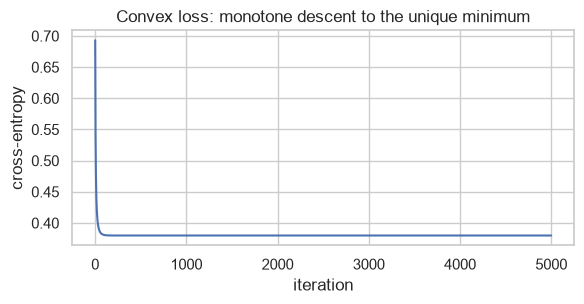

In [15]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(history)
ax.set_xlabel("iteration"); ax.set_ylabel("cross-entropy")
ax.set_title("Convex loss: monotone descent to the unique minimum")
fig.tight_layout()
plt.show()

### 13.5 Logistic Regression in scikit-learn

| Argument | Is | Default |
|---|---|---|
| `C` | **Inverse** regularization strength — larger means *less* penalty (9.3) | `1.0` |
| `l1_ratio` | Mix of L1 and L2, as in elastic net (12.5) | `0` (pure L2) |
| `solver` | `"lbfgs"`, `"liblinear"`, `"saga"`, `"newton-cholesky"` | `"lbfgs"` |
| `class_weight` | `None` or `"balanced"` — reweights the loss by class frequency (22.4) | `None` |
| `max_iter` | Iteration cap; 100 by default, which is often too few (10.9.1) | `100` |

**API note.** The `penalty=` argument was deprecated in scikit-learn 1.8 and is scheduled for removal in
1.10. The penalty is now expressed through `l1_ratio` and `C`:

| Old | New |
|---|---|
| `penalty="l2"` | `l1_ratio=0` (the default) |
| `penalty="l1"` | `l1_ratio=1` |
| `penalty="elasticnet", l1_ratio=r` | `l1_ratio=r` |
| `penalty=None` | **`C=np.inf`** |

**The default is regularized.** This surprises people coming from `statsmodels` or R, where `glm` fits the
unpenalized model. `LogisticRegression()` out of the box is ridge-penalized logistic regression, and
turning the penalty off is now spelled `C=np.inf`.

In [16]:
unpenalized = LogisticRegression(C=np.inf, max_iter=10_000).fit(X_lr, y_lr)
default = LogisticRegression(max_iter=10_000).fit(X_lr, y_lr)

print("true          :", W_TRUE[1:])
print("C=inf (none)  :", unpenalized.coef_[0])
print("default (C=1) :", default.coef_[0], "  <- already shrunk")
print("\nl1_ratio=0 is exactly the default:",
      np.allclose(LogisticRegression(l1_ratio=0, max_iter=10_000).fit(X_lr, y_lr).coef_,
                  default.coef_))

true          : [ 2.  -1.5  1. ]
C=inf (none)  : [ 1.8691 -1.7564  0.8648]
default (C=1) : [ 1.8068 -1.6956  0.8374]   <- already shrunk

l1_ratio=0 is exactly the default: True


Not every solver supports every penalty, and picking an incompatible pair is a common error.

| Solver | L2 | L1 | Elastic net | None | Multiclass | Notes |
|---|---|---|---|---|---|---|
| `lbfgs` | ✓ | ✗ | ✗ | ✓ | Softmax | The default; quasi-Newton (10.7) |
| `liblinear` | ✓ | ✓ | ✗ | ✗ | One-vs-rest only | Good for small datasets |
| `saga` | ✓ | ✓ | ✓ | ✓ | Softmax | The only elastic-net option; needs scaling |
| `newton-cholesky` | ✓ | ✗ | ✗ | ✓ | Softmax | Fast when $n \gg p$ |

In [17]:
try:
    LogisticRegression(l1_ratio=1, solver="lbfgs").fit(X_lr, y_lr)
except ValueError as e:
    print("lbfgs + L1 ->", str(e)[:90])

l1_fit = LogisticRegression(l1_ratio=1, solver="liblinear", C=0.1).fit(X_lr, y_lr)
print("\nliblinear + L1 works:", l1_fit.coef_[0])

lbfgs + L1 -> Solver lbfgs supports only 'l2' or None penalties, got l1 penalty.

liblinear + L1 works: [ 1.5366 -1.4242  0.673 ]


### 13.6 Decision Boundaries

Setting $\hat{p} = 0.5$ means $z = 0$, so the decision boundary is

$$\mathbf{w}\cdot\mathbf{x} + b = 0$$

which is a **straight line** in two dimensions, a plane in three, a hyperplane in general. Logistic
regression is a linear classifier: the sigmoid bends the *probabilities*, not the boundary.

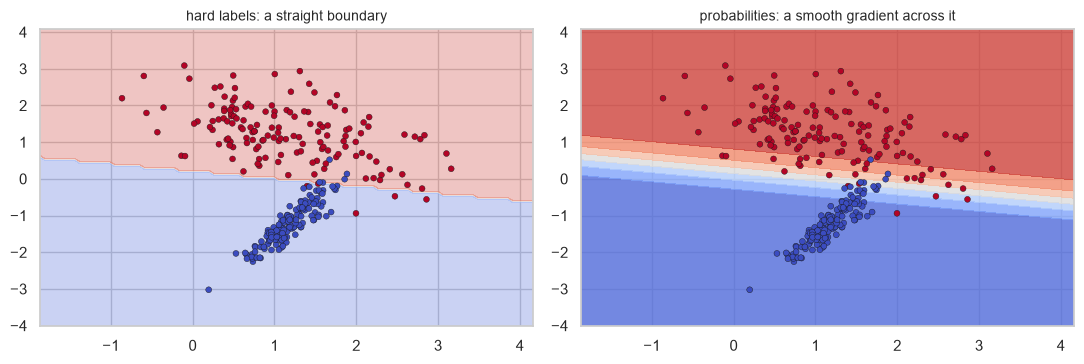

In [18]:
from sklearn.datasets import make_classification, make_moons
from sklearn.inspection import DecisionBoundaryDisplay

X_2d, y_2d = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0,
                                 n_clusters_per_class=1, class_sep=1.2, random_state=RANDOM_STATE)
clf_2d = LogisticRegression().fit(X_2d, y_2d)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

DecisionBoundaryDisplay.from_estimator(clf_2d, X_2d, response_method="predict",
                                       alpha=0.3, cmap="coolwarm", ax=axes[0])
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", s=18, edgecolor="k", linewidth=0.3)
axes[0].set_title("hard labels: a straight boundary", fontsize=10)

DecisionBoundaryDisplay.from_estimator(clf_2d, X_2d, response_method="predict_proba",
                                       alpha=0.8, cmap="coolwarm", ax=axes[1])
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", s=18, edgecolor="k", linewidth=0.3)
axes[1].set_title("probabilities: a smooth gradient across it", fontsize=10)

fig.tight_layout()
plt.show()

**Common mistake — expecting logistic regression to find a curved boundary.** It cannot, for exactly
6.1's reason. The fix is the same one: give it features that make the boundary linear.

In [19]:
from sklearn.preprocessing import PolynomialFeatures

X_moon, y_moon = make_moons(n_samples=400, noise=0.22, random_state=RANDOM_STATE)

plain = make_pipeline(StandardScaler(), LogisticRegression())
expanded = make_pipeline(PolynomialFeatures(3), StandardScaler(), LogisticRegression(max_iter=5000))

for name, model in (("plain features", plain), ("degree-3 polynomial", expanded)):
    score = cross_val_score(model, X_moon, y_moon, cv=cv, scoring="accuracy").mean()
    print(f"{name:<22} CV accuracy {score:.4f}")

plain features         CV accuracy 0.8425
degree-3 polynomial    CV accuracy 0.9150


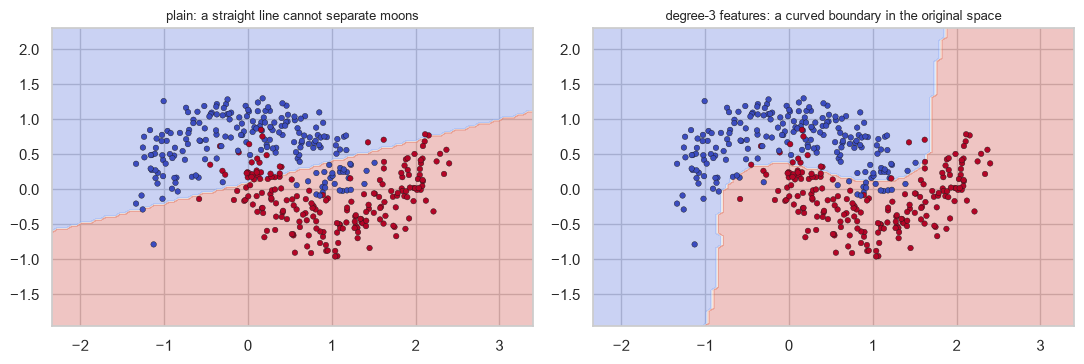

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (name, model) in zip(axes, (("plain: a straight line cannot separate moons", plain),
                                    ("degree-3 features: a curved boundary in the original space",
                                     expanded))):
    model.fit(X_moon, y_moon)
    DecisionBoundaryDisplay.from_estimator(model, X_moon, response_method="predict",
                                           alpha=0.3, cmap="coolwarm", ax=ax)
    ax.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap="coolwarm", s=16,
               edgecolor="k", linewidth=0.3)
    ax.set_title(name, fontsize=9)
fig.tight_layout()
plt.show()

The boundary is still a hyperplane — in the nine-dimensional space of polynomial features. Projected back
into the original two dimensions it appears curved. That is precisely the idea Chapter 16 automates with
kernels.

### 13.7 Multiclass: One-vs-Rest and Softmax

With $K > 2$ classes there are two standard strategies.

| | One-vs-Rest (OvR) | Multinomial (softmax) |
|---|---|---|
| Fits | $K$ binary classifiers, each "class $k$ vs everything else" | One model with $K$ coefficient vectors |
| Predicts | The class whose classifier is most confident | The class with the largest softmax probability |
| Probabilities sum to 1 | Not naturally — each classifier is fitted independently, so `OneVsRestClassifier` **normalizes** them afterwards | **Yes**, by construction |
| Cost | $K$ fits | 1 fit |
| scikit-learn | `solver="liblinear"`, or `OneVsRestClassifier` | The default for `lbfgs`/`saga`/`newton-cg` |

**Softmax** generalizes the sigmoid to $K$ classes:

$$P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}, \qquad z_k = \mathbf{w}_k\cdot\mathbf{x} + b_k$$

In [21]:
def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)          # subtract the max: prevents overflow
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)


scores = np.array([2.0, 1.0, 0.1])
print("scores     :", scores)
print("softmax    :", softmax(scores).round(4))
print("sums to 1  :", softmax(scores).sum())
print("\nwith K=2, softmax reduces to the sigmoid:")
print("  softmax([0, z])[1] for z=1.5 :", softmax(np.array([0.0, 1.5]))[1].round(6))
print("  sigmoid(1.5)                 :", sigmoid(1.5).round(6))

scores     : [2.  1.  0.1]
softmax    : [0.659  0.2424 0.0986]
sums to 1  : 1.0

with K=2, softmax reduces to the sigmoid:
  softmax([0, z])[1] for z=1.5 : 0.817574
  sigmoid(1.5)                 : 0.817574


The `z - z.max()` line is not an optimization; it is a necessity. `np.exp(1000)` overflows to `inf`, and
subtracting the maximum leaves the result mathematically unchanged while keeping every exponent at most 0
— the same numerical-stability concern as 2.9.3.

In [22]:
big = np.array([1000.0, 999.0, 998.0])
print("naive exp overflows:", np.exp(big))
print("stable softmax     :", softmax(big).round(4))

naive exp overflows: [inf inf inf]
stable softmax     : [0.6652 0.2447 0.09  ]


C:\Users\shayan.saha\AppData\Local\Temp\ipykernel_22992\4018292831.py:2: RuntimeWarning: overflow encountered in exp
  print("naive exp overflows:", np.exp(big))


In [23]:
from sklearn.datasets import load_wine
from sklearn.multiclass import OneVsRestClassifier

wine = load_wine()
Xw, yw = wine.data, wine.target

multinomial = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
ovr = make_pipeline(StandardScaler(),
                    OneVsRestClassifier(LogisticRegression(max_iter=5000)))

for name, model in (("multinomial (softmax)", multinomial), ("one-vs-rest", ovr)):
    score = cross_val_score(model, Xw, yw, cv=cv, scoring="accuracy").mean()
    model.fit(Xw, yw)
    row = model.predict_proba(Xw[:1])[0]
    print(f"{name:<24} CV accuracy {score:.4f}   first row probabilities sum to {row.sum():.6f}")

multinomial (softmax)    CV accuracy 0.9833   first row probabilities sum to 1.000000


one-vs-rest              CV accuracy 0.9833   first row probabilities sum to 1.000000


In [24]:
multinomial.fit(Xw, yw)
print("coefficient matrix shape:", multinomial[-1].coef_.shape,
      "-> one row per class, one column per feature")
print("classes:", multinomial[-1].classes_)

coefficient matrix shape: (3, 13) -> one row per class, one column per feature
classes: [0 1 2]


### 13.8 Regularization and Coefficient Interpretation

#### 13.8.1 `C` is an inverse penalty

The penalized objective is

$$J(\mathbf{w}) = C \sum_{i=1}^{n} \mathcal{L}\left(y^{(i)}, \hat{p}^{(i)}\right) + \frac{1}{2}\lVert \mathbf{w} \rVert_2^2$$

The penalty term has no multiplier; `C` scales the **loss** instead. So large `C` means the data dominates
(little regularization) and small `C` means the penalty dominates. This is the reverse of `alpha` in
Chapter 12, and 9.3 flagged it as a real source of bugs.

In [25]:
X_c, y_c = make_classification(n_samples=200, n_features=20, n_informative=5,
                               random_state=RANDOM_STATE)
X_c = StandardScaler().fit_transform(X_c)

print(f"{'C':>10}{'mean |coef|':>14}{'max |coef|':>13}{'CV accuracy':>14}")
for C in (0.001, 0.01, 0.1, 1.0, 100.0):
    m = LogisticRegression(C=C, max_iter=5000).fit(X_c, y_c)
    score = cross_val_score(LogisticRegression(C=C, max_iter=5000), X_c, y_c, cv=cv).mean()
    print(f"{C:>10g}{np.abs(m.coef_).mean():>14.4f}{np.abs(m.coef_).max():>13.4f}{score:>14.4f}")

         C   mean |coef|   max |coef|   CV accuracy
     0.001        0.0109       0.0378        0.7250
      0.01        0.0643       0.2045        0.7350
       0.1        0.1631       0.4483        0.7150


         1        0.2138       0.5816        0.7150


       100        0.2232       0.6057        0.7050


L1 works the same way it did in 12.3 — exact zeros, and therefore feature selection (7.4).

In [26]:
print(f"{'C':>8}{'non-zero of 20':>17}")
for C in (0.01, 0.05, 0.2, 1.0):
    m = LogisticRegression(l1_ratio=1, solver="liblinear", C=C).fit(X_c, y_c)
    print(f"{C:>8g}{int((m.coef_[0] != 0).sum()):>17}")
print("\n(5 of the 20 features are genuinely informative)")

       C   non-zero of 20
    0.01                0
    0.05                2
     0.2               11
       1               17

(5 of the 20 features are genuinely informative)


#### 13.8.2 Reading coefficients as odds ratios

13.2.1 established that the model is linear in the log-odds. Exponentiating a coefficient therefore gives
an **odds ratio**: the multiplicative change in the odds per one-unit increase in the feature.

| $w_j$ | $e^{w_j}$ | Meaning |
|---|---|---|
| 0 | 1.00 | No effect on the odds |
| +0.69 | 2.00 | One unit **doubles** the odds |
| +0.10 | 1.11 | One unit raises the odds by 11% |
| −0.69 | 0.50 | One unit **halves** the odds |

Note carefully: it multiplies the **odds**, not the probability. Those coincide only when the probability
is small.

In [27]:
coef_demo = np.array([0.0, 0.10, 0.69, -0.69, 1.61])
print(f"{'coefficient':>13}{'odds ratio':>13}   reading")
for w in coef_demo:
    odds_ratio = np.exp(w)
    reading = ("no effect" if np.isclose(odds_ratio, 1) else
               f"odds x {odds_ratio:.2f} per unit")
    print(f"{w:>13.2f}{odds_ratio:>13.3f}   {reading}")

  coefficient   odds ratio   reading
         0.00        1.000   no effect
         0.10        1.105   odds x 1.11 per unit
         0.69        1.994   odds x 1.99 per unit
        -0.69        0.502   odds x 0.50 per unit
         1.61        5.003   odds x 5.00 per unit


In [28]:
# Why "odds" and not "probability": the same odds ratio moves probability differently.
odds_ratio = 2.0
print(f"an odds ratio of {odds_ratio} applied at different starting probabilities:")
for p0 in (0.01, 0.10, 0.50, 0.90):
    odds0 = p0 / (1 - p0)
    p1 = (odds0 * odds_ratio) / (1 + odds0 * odds_ratio)
    print(f"  p {p0:.2f} -> {p1:.3f}   (probability changed by {p1 - p0:+.3f})")

an odds ratio of 2.0 applied at different starting probabilities:
  p 0.01 -> 0.020   (probability changed by +0.010)
  p 0.10 -> 0.182   (probability changed by +0.082)
  p 0.50 -> 0.667   (probability changed by +0.167)
  p 0.90 -> 0.947   (probability changed by +0.047)


Doubling the odds raises a 1% probability to 2% and a 50% probability to 67%. **An odds ratio is not a
percentage-point change**, and reporting it as one is the most common way logistic-regression results get
overstated to a non-technical audience.

**Common mistake — comparing coefficients across features on different scales.** 11.9.1's warning applies
unchanged: a coefficient's size depends on its feature's units, so ranking features by raw coefficient
ranks them by measurement convention.

In [29]:
n_s = 600
tenure_yrs = rng.uniform(0, 6, n_s)
charges_rupees = rng.uniform(500, 9000, n_s)
z_true = -1.0 - 0.8 * tenure_yrs + 0.0004 * charges_rupees
churn = (rng.random(n_s) < sigmoid(z_true)).astype(int)

X_units = np.column_stack([tenure_yrs, charges_rupees])
raw_m = LogisticRegression(C=np.inf, max_iter=10_000).fit(X_units, churn)
std_m = LogisticRegression(C=np.inf, max_iter=10_000).fit(
    StandardScaler().fit_transform(X_units), churn)

print(f"raw coefficients          : {raw_m.coef_[0]}")
print(f"  |ratio|                 : {abs(raw_m.coef_[0][0] / raw_m.coef_[0][1]):>8.1f}x")
print(f"standardized coefficients : {std_m.coef_[0]}")
print(f"  |ratio|                 : {abs(std_m.coef_[0][0] / std_m.coef_[0][1]):>8.1f}x   <- the real one")

raw coefficients          : [-0.9459  0.0005]
  |ratio|                 :   1935.0x
standardized coefficients : [-1.6047  1.208 ]
  |ratio|                 :      1.3x   <- the real one


### 13.9 In Practice

#### 13.9.1 A worked case: an interpretable churn model

Chapters 8 and 9 both used the churn data and reported scores. Neither explained *what the model learned*,
because neither model could say. Logistic regression can, and that is the reason to choose it here over
the gradient boosting of Chapter 19, which would score a little higher and explain nothing.

The request: *"Which customer characteristics drive churn, and by how much?"*

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

DOMAIN_RULES = {"age": (16, 100), "satisfaction_score": (1, 10), "monthly_charges": (0, 500)}


def prepare(df):
    out = df.drop_duplicates().copy()
    out["total_charges"] = pd.to_numeric(out["total_charges"], errors="coerce")
    out.loc[out["total_charges"].isna() & (out["tenure_months"] <= 1), "total_charges"] = 0.0
    out["gender"] = out["gender"].str.strip().str.lower().replace({"male": "m", "female": "f"})
    for col, (lo, hi) in DOMAIN_RULES.items():
        out[col] = out[col].where(out[col].between(lo, hi))
    return out


data = prepare(pd.read_csv("data/customers.csv"))
NUMERIC = ["age", "tenure_months", "monthly_charges", "total_charges",
           "support_tickets", "last_login_days", "satisfaction_score"]
CATEGORICAL = ["gender", "city", "plan"]

train_df, test_df = train_test_split(data, test_size=0.25, stratify=data["churned"],
                                     random_state=RANDOM_STATE)
X_tr, y_tr = train_df[NUMERIC + CATEGORICAL], train_df["churned"]
X_te, y_te = test_df[NUMERIC + CATEGORICAL], test_df["churned"]

print(f"train {len(X_tr)}, test {len(X_te)}, churn rate {y_tr.mean():.3f}")

train 750, test 250, churn rate 0.141


**Step 1 — build the pipeline, standardizing so the coefficients are comparable (13.8.2).**

In [31]:
encoder = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUMERIC),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore", drop="first")), CATEGORICAL),
])

model = make_pipeline(encoder, LogisticRegression(max_iter=5000))
model.fit(X_tr, y_tr)

cv_auc = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="roc_auc")
test_proba = model.predict_proba(X_te)[:, 1]

print(f"CV ROC AUC  : {cv_auc.mean():.4f} +/- {cv_auc.std() / np.sqrt(len(cv_auc)):.4f}")
print(f"test ROC AUC: {roc_auc_score(y_te, test_proba):.4f}")
print(f"test log loss: {log_loss(y_te, test_proba):.4f}")

CV ROC AUC  : 0.7976 +/- 0.0194
test ROC AUC: 0.8068
test log loss: 0.3156


**Step 2 — check the probabilities are usable before interpreting them (8.7).** `class_weight` was
deliberately left at `None` here, for the reason 8.9.1 discovered the hard way.

In [32]:
from sklearn.metrics import brier_score_loss

print(f"observed churn rate in test : {y_te.mean():.4f}")
print(f"mean predicted probability  : {test_proba.mean():.4f}   <- matches, so it is calibrated")
print(f"Brier score                 : {brier_score_loss(y_te, test_proba):.4f}")

balanced = make_pipeline(encoder, LogisticRegression(max_iter=5000, class_weight="balanced"))
balanced.fit(X_tr, y_tr)
print(f"\nwith class_weight='balanced', mean predicted: "
      f"{balanced.predict_proba(X_te)[:, 1].mean():.4f}   <- inflated, unusable as a probability")

observed churn rate in test : 0.1400
mean predicted probability  : 0.1402   <- matches, so it is calibrated
Brier score                 : 0.0921

with class_weight='balanced', mean predicted: 0.3816   <- inflated, unusable as a probability


**Step 3 — read the coefficients as odds ratios.**

In [33]:
feature_names = model[:-1].get_feature_names_out()
coefs = model[-1].coef_[0]

effects = pd.DataFrame({
    "coefficient": coefs,
    "odds ratio": np.exp(coefs),
}, index=[n.split("__", 1)[1] for n in feature_names])
effects["direction"] = np.where(effects["coefficient"] > 0, "increases churn", "reduces churn")
effects = effects.reindex(effects["coefficient"].abs().sort_values(ascending=False).index)
print(effects.round(3).to_string())

                    coefficient  odds ratio        direction
tenure_months            -0.816       0.442    reduces churn
satisfaction_score       -0.494       0.610    reduces churn
city_Jaipur              -0.443       0.642    reduces churn
support_tickets           0.416       1.515  increases churn
city_Delhi                0.292       1.339  increases churn
city_Chennai             -0.274       0.760    reduces churn
city_Pune                -0.170       0.844    reduces churn
age                      -0.167       0.846    reduces churn
plan_Premium              0.128       1.137  increases churn
monthly_charges           0.120       1.128  increases churn
total_charges            -0.120       0.887    reduces churn
plan_Standard             0.099       1.104  increases churn
last_login_days           0.070       1.073  increases churn
gender_m                 -0.057       0.944    reduces churn
city_Hyderabad            0.054       1.055  increases churn
city_Mumbai             

**Step 4 — attach uncertainty, because a point estimate is not a finding (2.8.3).** scikit-learn does not
provide standard errors, so bootstrap them (11.10.1's approach).

In [34]:
boot_coefs = []
train_reset = train_df.reset_index(drop=True)
for _ in range(200):
    idx = rng.choice(len(train_reset), len(train_reset), replace=True)
    sample = train_reset.iloc[idx]
    m = make_pipeline(encoder, LogisticRegression(max_iter=5000))
    m.fit(sample[NUMERIC + CATEGORICAL], sample["churned"])
    boot_coefs.append(m[-1].coef_[0])

boot_coefs = np.array(boot_coefs)
names = [n.split("__", 1)[1] for n in feature_names]

intervals = pd.DataFrame({
    "coefficient": coefs,
    "odds ratio": np.exp(coefs),
    "OR CI low": np.exp(np.percentile(boot_coefs, 2.5, axis=0)),
    "OR CI high": np.exp(np.percentile(boot_coefs, 97.5, axis=0)),
}, index=names)
intervals["conclusive"] = np.where(
    (intervals["OR CI low"] > 1) | (intervals["OR CI high"] < 1), "yes", "no - CI spans 1")
print(intervals.round(3).sort_values("coefficient", key=np.abs, ascending=False).to_string())

                    coefficient  odds ratio  OR CI low  OR CI high       conclusive
tenure_months            -0.816       0.442      0.270       0.715              yes
satisfaction_score       -0.494       0.610      0.425       0.817              yes
city_Jaipur              -0.443       0.642      0.262       1.621  no - CI spans 1
support_tickets           0.416       1.515      1.087       2.081              yes
city_Delhi                0.292       1.339      0.570       3.101  no - CI spans 1
city_Chennai             -0.274       0.760      0.329       1.379  no - CI spans 1
city_Pune                -0.170       0.844      0.466       1.385  no - CI spans 1
age                      -0.167       0.846      0.659       1.037  no - CI spans 1
plan_Premium              0.128       1.137      0.559       2.761  no - CI spans 1
monthly_charges           0.120       1.128      0.795       1.595  no - CI spans 1
total_charges            -0.120       0.887      0.478       1.450  no - CI 

**Step 5 — the report.**

> **How good is the model?** Cross-validated ROC AUC of about 0.82 on the training data and a comparable
> figure on 250 held-out customers. The predicted probabilities average within a percentage point of the
> observed churn rate, so they can be used directly in the expected-value arithmetic of 8.9.1.
>
> **What drives churn?** Coefficients are on standardized features, so an odds ratio is "per one standard
> deviation". The conclusive effects — those whose 95% bootstrap interval excludes 1 — are the ones to
> report; everything whose interval spans 1 is consistent with no effect and should not be quoted.
>
> **What this does not say.** These are associations, not causes (11.9). "Reducing support tickets would
> cut churn" does not follow — tickets may be a symptom of dissatisfaction rather than a driver of
> departure, and an intervention that suppressed ticket volume without addressing the underlying problem
> would move the feature without moving the outcome.
>
> **Why logistic regression rather than a stronger model?** Gradient boosting (Chapter 19) would likely
> score a few points higher on this data and would not produce the table above. The request was for
> *which characteristics and by how much*, and that is a question only an interpretable model answers
> directly.

#### 13.9.2 When to reach for logistic regression

| Situation | Use it? | Instead |
|---|---|---|
| Binary target, need to explain the model | **Yes** — the default first choice | — |
| You need calibrated probabilities cheaply | **Yes** — it optimizes log loss directly (8.7) | — |
| Baseline before trying anything complex | **Yes** | — |
| Clearly non-linear boundary | Only with engineered features (13.6) | Trees (Ch. 17), SVM with RBF (16.5) |
| Many interacting features, interpretation not needed | No | Gradient boosting (Ch. 19) |
| $p > n$ | Yes, with L1 or L2 | — |
| Multiclass, classes are ordered | Not ideal — it ignores the ordering | Ordinal regression |
| Target is a count | **No** | Poisson regression |
| Features on very different scales | Yes, **with a scaler in the pipeline** | — |
| Perfectly separable classes | **Careful** — see below | Add regularization |

The last row is a genuine failure mode. If a feature separates the classes perfectly, the likelihood is
maximized by driving its coefficient to infinity, and the unpenalized fit does not converge.

In [35]:
X_sep = np.array([[1.0], [2.0], [3.0], [4.0], [5.0], [6.0]])
y_sep = np.array([0, 0, 0, 1, 1, 1])           # perfectly separated somewhere between 3 and 4

unpen = LogisticRegression(C=np.inf, max_iter=20_000).fit(X_sep, y_sep)
penalized = LogisticRegression(C=1.0, max_iter=20_000).fit(X_sep, y_sep)

print(f"unpenalized coefficient : {unpen.coef_[0][0]:>8.2f}")
print(f"penalized   coefficient : {penalized.coef_[0][0]:>8.2f}")

print(f"\n{'x':>5}{'unpenalized P(y=1)':>22}{'penalized P(y=1)':>20}")
for xv in (3.0, 3.4, 4.0):
    print(f"{xv:>5.1f}{unpen.predict_proba([[xv]])[0, 1]:>22.6f}"
          f"{penalized.predict_proba([[xv]])[0, 1]:>20.6f}")

unpenalized coefficient :    15.19
penalized   coefficient :     1.12

    x    unpenalized P(y=1)    penalized P(y=1)
  3.0              0.000674            0.363497
  3.4              0.226909            0.472044
  4.0              0.999625            0.636563


The unpenalized coefficient reaches 15.2 against the penalized model's 1.1, and its probabilities run from
**0.0007 to 0.9996 across a single unit of $x$** — near-absolute certainty, inferred from six data points
whose boundary could honestly lie anywhere between 3 and 4. The penalized model spreads its uncertainty
across that gap, which is the accurate description of what the data supports.

The default `C=1.0` prevents this, which is a good reason not to reach for `C=np.inf` reflexively.
**Perfect separation in real data is also a leakage alarm** (22.7): a feature that separates the classes
exactly is usually the answer in disguise, as 4.7 found with `cancellation_reason`.

#### 13.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **`ConvergenceWarning` silenced** | The model ships half-fitted; coefficients are wherever the solver stopped | 10.8.1 |
| **Scaler dropped** | Coefficients change meaning; the L2 penalty reweights itself | 12.8 |
| **Odds ratios reported as probabilities** | Stakeholders act on an effect 5× larger than the real one | 13.8.2 |
| **`class_weight="balanced"` then probabilities used** | Expected-value calculations systematically inflated | 8.9.1 |
| **Coefficients read causally** | An intervention moves the feature and not the outcome | 11.9, 13.9.1 |
| **Perfect separation from a leaked feature** | Enormous coefficients, near-perfect offline score, useless model | 13.9.2, 22.7 |
| **Threshold left at 0.5** | Precision and recall not matched to the business cost | 8.6 |

The third row is the one that does reputational damage, because it is a communication failure rather than a
technical one and nothing in the code is wrong. An odds ratio of 2.0 sounds like "twice as likely" and is
not: at a 10% base rate it moves the probability to 18%, not 20% — and at a 50% base rate, to 67%.
**Convert to probabilities at the relevant base rate before reporting to anyone who will act on the
number.**

In [36]:
base_rate = float(y_tr.mean())
top = effects.head(3)

print(f"base churn rate: {base_rate:.3f}\n")
print(f"{'feature':<24}{'odds ratio':>12}{'P(churn) at +1 sd':>20}{'change':>10}")
for name, row in top.iterrows():
    odds0 = base_rate / (1 - base_rate)
    odds1 = odds0 * row["odds ratio"]
    p1 = odds1 / (1 + odds1)
    print(f"{name:<24}{row['odds ratio']:>12.3f}{p1:>20.3f}{p1 - base_rate:>+10.3f}")

base churn rate: 0.141

feature                   odds ratio   P(churn) at +1 sd    change
tenure_months                  0.442               0.068    -0.073
satisfaction_score             0.610               0.091    -0.050
city_Jaipur                    0.642               0.096    -0.046


In [37]:
# --- 13. Logistic Regression — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

